<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week11/day1-2/Stock_Prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.5 MB/s eta 0:00:00


In [3]:
import torch
import gensim
import spacy
import sklearn

In [4]:
!wget https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip

--2026-07-03 11:54:32--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip [following]
--2026-07-03 11:54:32--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200

In [5]:

!unzip "/content/Intro to Recurrent Neural Networks LSTM  GRU.zip"

Archive:  /content/Intro to Recurrent Neural Networks LSTM  GRU.zip
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AABA_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AAPL_2006-01-01_to_2018-01-01.csv  
 extracting: Intro to Recurrent Neural Networks LSTM  GRU/all_stocks_2006-01-01_to_2018-01-01.csv.zip  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/all_stocks_2017-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AMZN_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AXP_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/BA_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/CAT_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/CSCO_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/CVX_2006-01-01_t

In [6]:
DS_FILEPATH = "/content/Intro to Recurrent Neural Networks LSTM  GRU/IBM_2006-01-01_to_2018-01-01.csv"

In [7]:

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error

In [8]:
df = pd.read_csv(DS_FILEPATH)
print(df.head().to_string())


         Date   Open   High    Low  Close    Volume Name
0  2006-01-03  82.45  82.55  80.81  82.06  11715200  IBM
1  2006-01-04  82.20  82.50  81.33  81.95   9840600  IBM
2  2006-01-05  81.40  82.90  81.00  82.50   7213500  IBM
3  2006-01-06  83.95  85.03  83.41  84.95   8197400  IBM
4  2006-01-09  84.10  84.25  83.38  83.73   6858200  IBM


In [19]:
df = df[["Date", "Open", "Close"]]
# Convert Date to datetime and sort chronologically (CSV order isn't guaranteed)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())

        Date   Open  Close
0 2006-01-03  82.45  82.06
1 2006-01-04  82.20  81.95
2 2006-01-05  81.40  82.50
3 2006-01-06  83.95  84.95
4 2006-01-09  84.10  83.73


In [20]:
# Target = next day's Close price, i.e. shift Close up by one row
df["Target"] = df["Close"].shift(-1)

# The last row will have NaN target (no "next day" to predict) — drop it
df = df.dropna().reset_index(drop=True)

print("Shape after creating target and dropping last row:", df.shape)
print(df.head().to_string())

Shape after creating target and dropping last row: (3018, 4)
        Date   Open  Close  Target
0 2006-01-03  82.45  82.06   81.95
1 2006-01-04  82.20  81.95   82.50
2 2006-01-05  81.40  82.50   84.95
3 2006-01-06  83.95  84.95   83.73
4 2006-01-09  84.10  83.73   84.07


In [22]:
from sklearn.preprocessing import MinMaxScaler

close_scaler = MinMaxScaler(feature_range=(0, 1))
open_scaler = MinMaxScaler(feature_range=(0, 1))

close_scaler.fit(df[["Close"]])
open_scaler.fit(df[["Open"]])

df["Open_scaled"] = open_scaler.transform(df[["Open"]])
df["Close_scaled"] = close_scaler.transform(df[["Close"]])

# Target is next-day Close, so reuse close_scaler — but rename the column
# to "Close" first so sklearn doesn't complain about the mismatched name
df["Target_scaled"] = close_scaler.transform(df[["Target"]].rename(columns={"Target": "Close"}))

print(df.head().to_string())
print("Close range:", df["Close"].min(), "-", df["Close"].max())
print("Scaled Close range:", df["Close_scaled"].min(), "-", df["Close_scaled"].max())

        Date   Open  Close  Target  Open_scaled  Close_scaled  Target_scaled
0 2006-01-03  82.45  82.06   81.95     0.068073      0.071637       0.070873
1 2006-01-04  82.20  81.95   82.50     0.066321      0.070873       0.074691
2 2006-01-05  81.40  82.50   84.95     0.060712      0.074691       0.091698
3 2006-01-06  83.95  84.95   83.73     0.078589      0.091698       0.083229
4 2006-01-09  84.10  83.73   84.07     0.079641      0.083229       0.085589
Close range: 71.74 - 215.8
Scaled Close range: 0.0 - 1.0000000000000002


In [23]:
# Split chronologically (never shuffle time series before splitting!)
# 70% train, 15% val, 15% test
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

print("Train:", train_df.shape, train_df["Date"].min(), "to", train_df["Date"].max())
print("Val:  ", val_df.shape, val_df["Date"].min(), "to", val_df["Date"].max())
print("Test: ", test_df.shape, test_df["Date"].min(), "to", test_df["Date"].max())

Train: (2112, 7) 2006-01-03 00:00:00 to 2014-05-23 00:00:00
Val:   (453, 7) 2014-05-27 00:00:00 to 2016-03-11 00:00:00
Test:  (453, 7) 2016-03-14 00:00:00 to 2017-12-28 00:00:00


In [24]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

SEQUENCE_LENGTH = 30  # use 30 past days to predict the next day's close

class StockDataset(Dataset):
    def __init__(self, dataframe, sequence_length=SEQUENCE_LENGTH):
        # Features: scaled Open and Close for each day in the window
        self.features = dataframe[["Open_scaled", "Close_scaled"]].values.astype(np.float32)
        # Labels: scaled Target (next day's close) at the END of each window
        self.targets = dataframe["Target_scaled"].values.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        # Number of valid windows we can build
        return len(self.features) - self.sequence_length + 1

    def __getitem__(self, idx):
        # Window of `sequence_length` days of features
        x = self.features[idx : idx + self.sequence_length]
        # Target corresponds to the last day in that window
        y = self.targets[idx + self.sequence_length - 1]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        return x, y

print("StockDataset class defined")

StockDataset class defined


In [25]:
BATCH_SIZE = 32

train_dataset = StockDataset(train_df, SEQUENCE_LENGTH)
val_dataset = StockDataset(val_df, SEQUENCE_LENGTH)
test_dataset = StockDataset(test_df, SEQUENCE_LENGTH)

print("Train sequences:", len(train_dataset))
print("Val sequences:  ", len(val_dataset))
print("Test sequences: ", len(test_dataset))

# Shuffle only the training loader — never shuffle val/test time series order
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check: pull one batch and inspect shapes
x_batch, y_batch = next(iter(train_loader))
print("x_batch shape:", x_batch.shape)  # [batch_size, sequence_length, num_features]
print("y_batch shape:", y_batch.shape)  # [batch_size]

Train sequences: 2083
Val sequences:   424
Test sequences:  424
x_batch shape: torch.Size([32, 30, 2])
y_batch shape: torch.Size([32])


In [26]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer: processes the sequence of (Open_scaled, Close_scaled) pairs
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # input shape: [batch, seq_len, features]
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Dropout before the final dense layer, for extra regularization
        self.dropout = nn.Dropout(dropout)

        # Dense layer maps the LSTM's final hidden state to a single predicted value
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: [batch_size, sequence_length, input_size]
        lstm_out, (hidden, cell) = self.lstm(x)

        # We only need the output from the LAST time step for prediction
        last_out = lstm_out[:, -1, :]   # shape: [batch_size, hidden_size]

        out = self.dropout(last_out)
        out = self.fc(out)              # shape: [batch_size, 1]

        return out.squeeze(-1)          # shape: [batch_size] — matches y_batch shape

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = LSTMModel(input_size=2, hidden_size=64, num_layers=2, dropout=0.2).to(device)
print(model)

# Sanity check: run one batch through the untrained model
x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

with torch.no_grad():
    preds = model(x_batch)

print("preds shape:", preds.shape)   # should match y_batch shape: [32]
print("y_batch shape:", y_batch.shape)

Using device: cpu
LSTMModel(
  (lstm): LSTM(2, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
preds shape: torch.Size([32])
y_batch shape: torch.Size([32])


In [28]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)

print("Training/validation functions defined")

Training/validation functions defined


In [30]:
NUM_EPOCHS = 50

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Keep track of the best model (lowest val loss) so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# Load the best model weights (lowest validation loss) before moving on
model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.6f}")

Epoch   1/50 | Train Loss: 0.043799 | Val Loss: 0.001077
Epoch   5/50 | Train Loss: 0.002196 | Val Loss: 0.001051
Epoch  10/50 | Train Loss: 0.001702 | Val Loss: 0.001932
Epoch  15/50 | Train Loss: 0.001636 | Val Loss: 0.001202
Epoch  20/50 | Train Loss: 0.001333 | Val Loss: 0.000910
Epoch  25/50 | Train Loss: 0.001509 | Val Loss: 0.000564
Epoch  30/50 | Train Loss: 0.001244 | Val Loss: 0.000656
Epoch  35/50 | Train Loss: 0.001203 | Val Loss: 0.000523
Epoch  40/50 | Train Loss: 0.001027 | Val Loss: 0.000551
Epoch  45/50 | Train Loss: 0.001061 | Val Loss: 0.000439
Epoch  50/50 | Train Loss: 0.000939 | Val Loss: 0.000444

Best validation loss: 0.000408


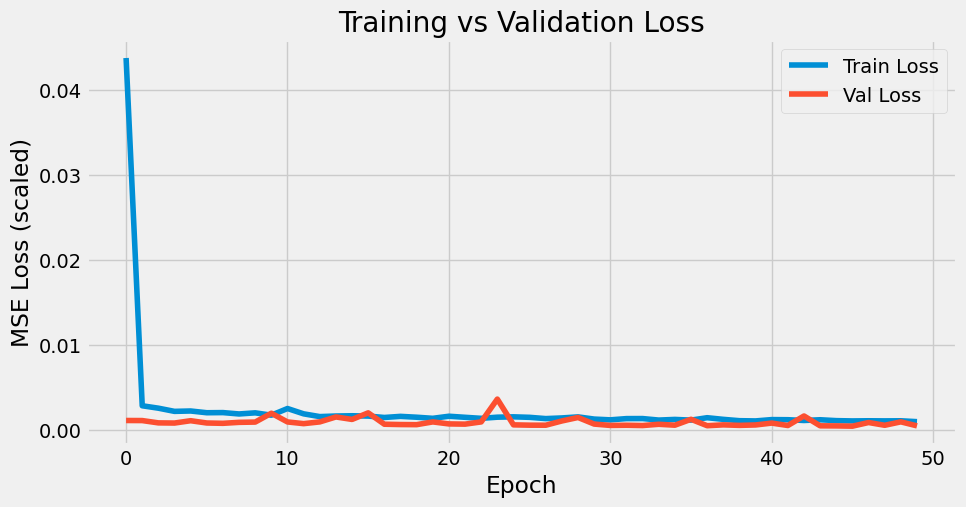

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled)")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [32]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        preds = model(x_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

print("Predictions shape:", all_preds.shape)
print("Targets shape:", all_targets.shape)

Predictions shape: (424,)
Targets shape: (424,)


In [33]:
# Predictions and targets are scaled (0-1) — convert back to actual prices
# using close_scaler, since Target/Close share the same price scale
preds_real = close_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
targets_real = close_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

print("Sample predictions vs actual (first 10):")
for p, t in zip(preds_real[:10], targets_real[:10]):
    print(f"  Predicted: ${p:.2f}   Actual: ${t:.2f}")

Sample predictions vs actual (first 10):
  Predicted: $146.84   Actual: $149.08
  Predicted: $147.31   Actual: $150.47
  Predicted: $147.94   Actual: $147.07
  Predicted: $147.97   Actual: $145.94
  Predicted: $147.20   Actual: $145.27
  Predicted: $146.21   Actual: $144.13
  Predicted: $145.04   Actual: $144.25
  Predicted: $143.99   Actual: $146.47
  Predicted: $143.91   Actual: $147.29
  Predicted: $144.27   Actual: $147.34


In [34]:
from sklearn.metrics import r2_score

r2 = r2_score(targets_real, preds_real)
print(f"R² score on test set: {r2:.4f}")

R² score on test set: 0.9396


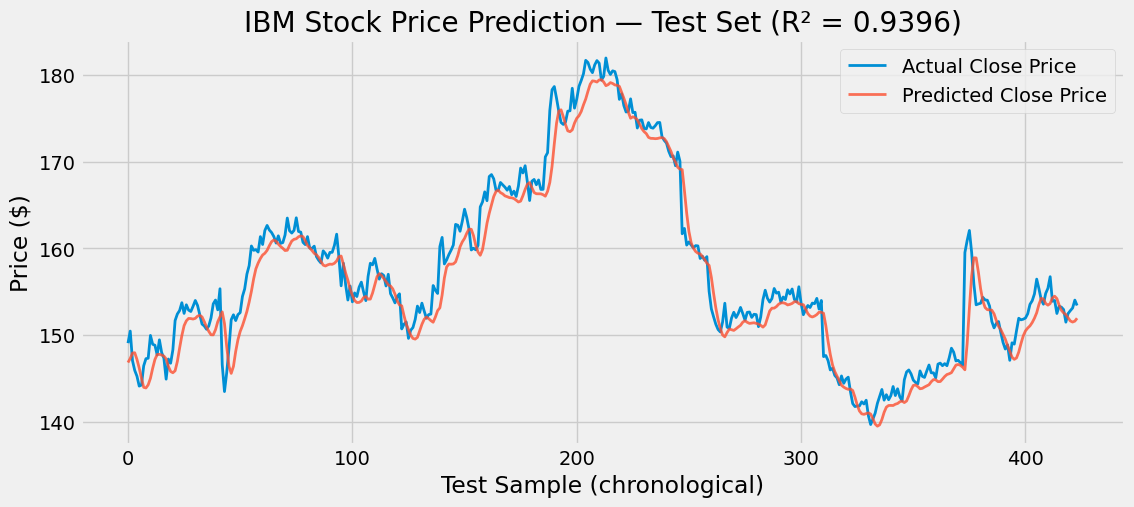

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(targets_real, label="Actual Close Price", linewidth=2)
plt.plot(preds_real, label="Predicted Close Price", linewidth=2, alpha=0.8)
plt.xlabel("Test Sample (chronological)")
plt.ylabel("Price ($)")
plt.title(f"IBM Stock Price Prediction — Test Set (R² = {r2:.4f})")
plt.legend()
plt.show()

In [36]:
import joblib

# Save both scalers — you'll need open_scaler if you ever re-scale new Open
# input, and close_scaler to inverse-transform any future predictions
joblib.dump(close_scaler, "close_scaler.pkl")
joblib.dump(open_scaler, "open_scaler.pkl")

# Save the trained model weights too, so you don't have to retrain from scratch
torch.save(model.state_dict(), "lstm_stock_model.pth")

print("Saved: close_scaler.pkl, open_scaler.pkl, lstm_stock_model.pth")

Saved: close_scaler.pkl, open_scaler.pkl, lstm_stock_model.pth
